In [6]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                               f1_score, confusion_matrix, classification_report,
                               roc_auc_score, roc_curve)

df = pd.read_csv("../data/processed/final_features.csv")

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

X = df.drop(columns=['Converted'])
y = df['Converted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("✅ Model trained and ready for evaluation")

✅ Model trained and ready for evaluation


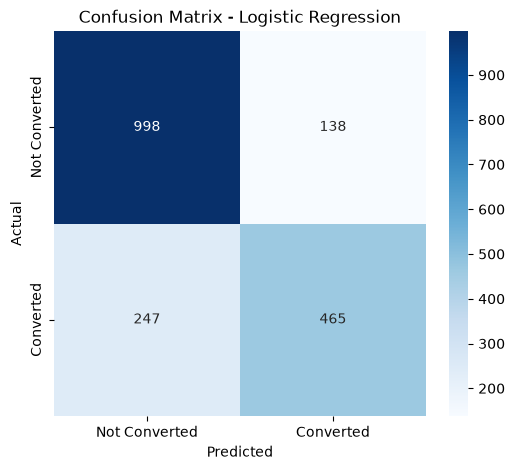

              precision    recall  f1-score   support

           0       0.80      0.88      0.84      1136
           1       0.77      0.65      0.71       712

    accuracy                           0.79      1848
   macro avg       0.79      0.77      0.77      1848
weighted avg       0.79      0.79      0.79      1848



In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Converted', 'Converted'],
            yticklabels=['Not Converted', 'Converted'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test, y_pred))

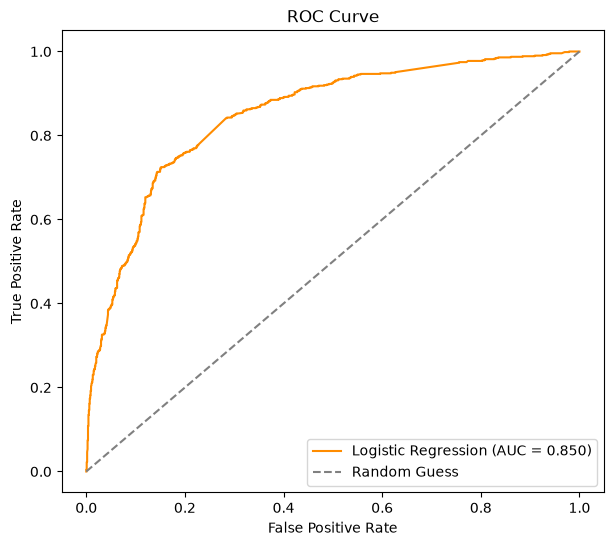

AUC Score: 0.8498


In [8]:
auc_score = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.3f})', color='darkorange')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print(f"AUC Score: {auc_score:.4f}")

In [9]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("Top 15 features INCREASING conversion probability:")
print(coefficients.head(15))

print("\nTop 15 features DECREASING conversion probability:")
print(coefficients.tail(15))

Top 15 features INCREASING conversion probability:
                                              Feature  Coefficient
0                         Total Time Spent on Website     1.106204
3   What is your current occupation_Working Profes...     0.712668
4                           Lead Origin_Lead Add Form     0.674240
23                                    Country_Unknown     0.385100
20                       Lead Source_Welingak Website     0.374206
6             What is your current occupation_Unknown     0.361151
17                             Lead Source_Olark Chat     0.163606
12                                 Lead Source_Google     0.126485
2                                         TotalVisits     0.126053
19                         Lead Source_Organic Search     0.098753
24                            City_Other Metro Cities     0.056641
7                               Lead Source_Reference     0.054919
8          What is your current occupation_Unemployed     0.048301
26         

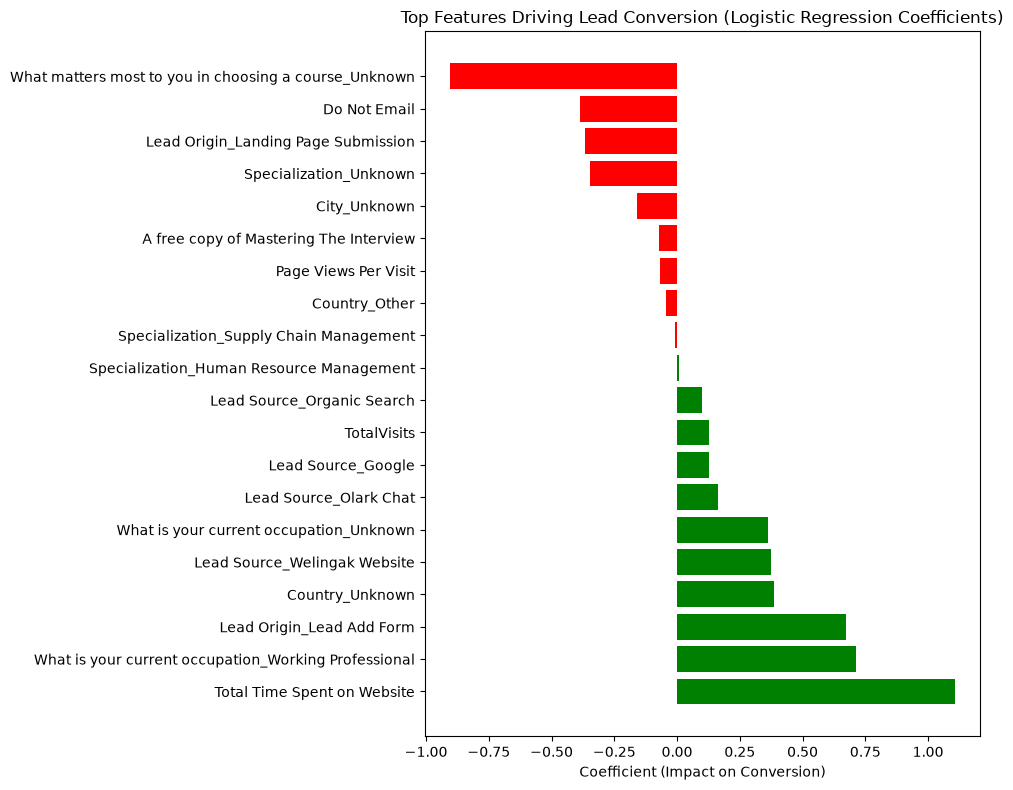

In [10]:
plt.figure(figsize=(10,8))
top_bottom = pd.concat([coefficients.head(10), coefficients.tail(10)])
colors = ['green' if x > 0 else 'red' for x in top_bottom['Coefficient']]
plt.barh(top_bottom['Feature'], top_bottom['Coefficient'], color=colors)
plt.title('Top Features Driving Lead Conversion (Logistic Regression Coefficients)')
plt.xlabel('Coefficient (Impact on Conversion)')
plt.tight_layout()
plt.show()